In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
import os

In [3]:
titanic_path = kagglehub.competition_download('titanic')

print('Data source import complete.')

100%|██████████| 34.1k/34.1k [00:00<00:00, 11.5MB/s]

Extracting files...
Data source import complete.


# Основной код

In [4]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from catboost import CatBoostClassifier, cv, Pool
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as rmse

In [34]:
train_data = pd.read_csv(titanic_path + '/train.csv')
test_data = pd.read_csv(titanic_path + '/test.csv')
train_data['Fare'] = np.log1p(train_data['Fare'])

# оптимизация линейной регрессии по MSE (age - гауссово распределение)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
test_data['Age'] = test_data['Age'].fillna(train_data['Age'].mean())

def age_stage(data):
    mu = data['Age'].mean()
    sigma = data['Age'].std()
    bins = [0, mu-sigma, mu+sigma, data['Age'].max() + 1]
    print(bins)
    data['Age_stage'] = pd.cut(data['Age'], bins=bins, labels=['child', 'adult', 'old'], right=False)

age_stage(train_data)
age_stage(test_data)


train_data['Embarked'] = train_data['Embarked'].fillna('S')
test_data['Embarked'] = test_data['Embarked'].fillna('S')

train_data['Fare'] = train_data['Fare'].fillna(train_data['Fare'].median())
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())



unused_features = ['Cabin', 'Name', "Ticket"]
cat_features = ['Embarked', 'Sex', 'Age_stage']
num_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

[0, np.float64(16.697102421055938), np.float64(42.7011328730617), 81.0]
[0, np.float64(17.517937294905757), np.float64(42.79126900962562), 77.0]


In [35]:
X = train_data[num_features + cat_features]
print(X.isnull().sum())
y = train_data['Survived']

train_pool = Pool(X, y, cat_features=cat_features)
params = {
    'loss_function': 'Logloss',
    'iterations': 500,
    'early_stopping_rounds': 20,
    'depth': 3,
    'verbose': False,
    'eval_metric': 'Accuracy',
}


cv_results = cv(
    params=params,
    pool=train_pool,
    fold_count=5,
    inverted=False,
    shuffle=True,
    partition_random_seed=42,
    stratified=True,
)

best_iteration = cv_results['test-Accuracy-mean'].idxmax()
best_accuracy = cv_results.loc[best_iteration, 'test-Accuracy-mean']
print(best_iteration, best_accuracy)


Pclass       0
Age          0
SibSp        0
Parch        0
Fare         0
Embarked     0
Sex          0
Age_stage    0
dtype: int64
Training on fold [0/5]

bestTest = 0.8324022346
bestIteration = 8

Training on fold [1/5]

bestTest = 0.7597765363
bestIteration = 18

Training on fold [2/5]

bestTest = 0.7752808989
bestIteration = 2

Training on fold [3/5]

bestTest = 0.8483146067
bestIteration = 3

Training on fold [4/5]

bestTest = 0.8248587571
bestIteration = 7

8 0.8002739213990276


In [36]:
final_model = CatBoostClassifier(
    iterations=best_iteration+1,
    loss_function='Logloss',
    random_seed=42,
    verbose=100
)
final_model.fit(train_pool)

Learning rate set to 0.5
0:	learn: 0.5424435	total: 1.5ms	remaining: 12ms
8:	learn: 0.3869944	total: 10.5ms	remaining: 0us


In [37]:
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': final_model.predict(test_data[num_features + cat_features]).astype(int)
})
submission.to_csv("submission.csv", index=False)

In [38]:
!kaggle competitions submit -c titanic -f submission.csv -m "Message"

100% 2.77k/2.77k [00:00<00:00, 15.5kB/s]
Successfully submitted to Titanic - Machine Learning from Disaster

# Промежуточные выводы и гипотезы

## 1
Женщины выживают с вероятностью 0.74, но если pclass!=3, то они скорее всего выживают. Если pclass=3,то там вероятность 0.5
Рассмотрим редкие случаи у pclass=1|2 и выясним случайно ли они погибли или есть какая-то общая закономерность

In [ ]:
train_data[(train_data['Sex'] == 'female') & (train_data['Pclass'] == 1) & (train_data['Survived'] == 0)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
177,178,0,1,"Isham, Miss. Ann Elizabeth",female,50.0,0,0,PC 17595,28.7125,C49,C
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S
498,499,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1,2,113781,151.5500,C22 C26,S


In [ ]:
train_data[(train_data['Sex'] == 'female') & (train_data['Pclass'] == 2) & (train_data['Survived'] == 0)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
41,42,0,2,"Turpin, Mrs. William John Robert (Dorothy Ann ...",female,27.0,1,0,11668,21.0,NaN,S
199,200,0,2,"Yrois, Miss. Henriette (""Mrs Harbeck"")",female,24.0,0,0,248747,13.0,NaN,S
312,313,0,2,"Lahtinen, Mrs. William (Anna Sylfven)",female,26.0,1,1,250651,26.0,NaN,S
357,358,0,2,"Funk, Miss. Annie Clemmer",female,38.0,0,0,237671,13.0,NaN,S
772,773,0,2,"Mack, Mrs. (Mary)",female,57.0,0,0,S.O./P.P. 3,10.5,E77,S
854,855,0,2,"Carter, Mrs. Ernest Courtenay (Lilian Hughes)",female,44.0,1,0,244252,26.0,NaN,S


## 2
Признак cabin по интуиции несет какую-то информацию о таргете, то есть возможно в каком-то секторе смертей было больше. Но, смотря на barplot по Cabin я не вижу особо чего-то интересного, может быть дело в номере кабины? Тоже нет, короче на кабину пока забьем.

## 3
За embarked ниче не могу сказать. По mutual_info он не лишний, рассмотрю еще feature importance.

# 4

Age - можно разделить на 3 группы: дети,взрослые и пожилые. Распределение гауссово - хорошо делится на три бина.
Заполнить пропуски, оптимизировав линейную регрессию по MSE, при этом на трейн оставить только значимые для Age фичи - Embarked, Cabin убрать


## 5

Fare значимый по mutual_info, поэтому пока оставлю его просто как есть - возможно его стоит логарифмировать для лучшего распределения, но Catboost итак справится

# Эксперименты

## Fare

<Axes: ylabel='Fare'>

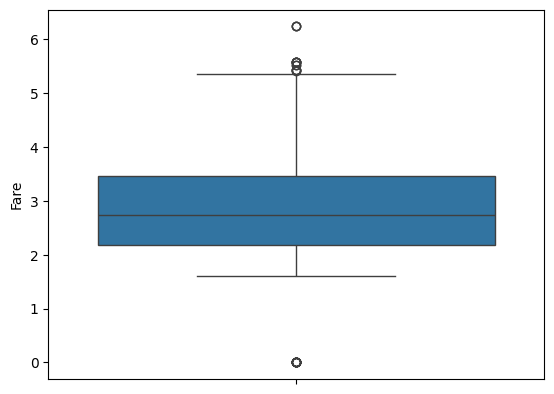

In [13]:
sns.boxplot(y=np.log1p(train_data['Fare']))

<Axes: ylabel='Fare'>

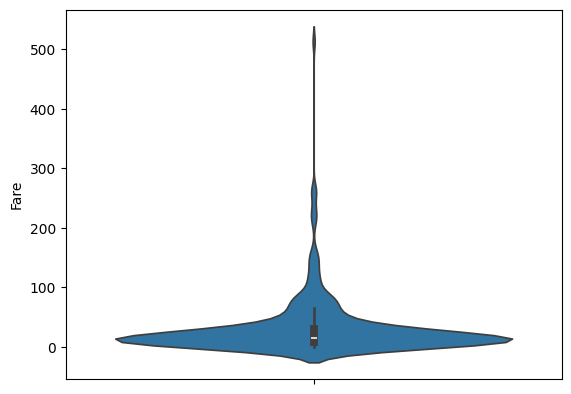

In [15]:
sns.violinplot(y=train_data['Fare'])

<Axes: xlabel='Fare', ylabel='Density'>

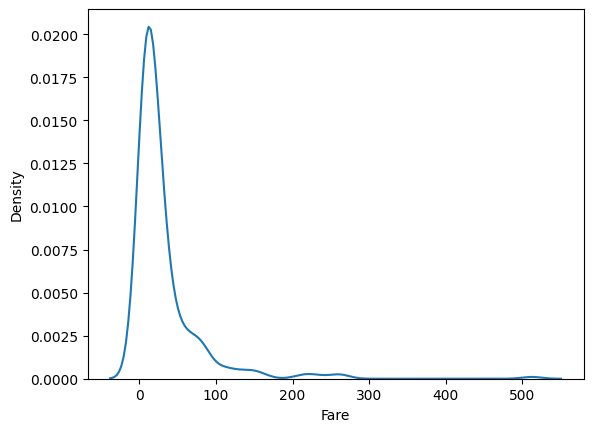

In [18]:
sns.kdeplot(train_data['Fare'])

In [21]:
len(train_data[train_data['Fare'] == 0])

15

In [22]:
train_data['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [34]:
mi_null = []

for _ in range(100):
    y_perm = np.random.permutation(train_data['Survived'])
    mi_null.append(mutual_info_regression(train_data[['Fare']], y_perm, discrete_features=False)[0])

threshold = np.percentile(mi_null, 95)
print(threshold)

mi_vals = []
for _ in range(100):
    mi_vals.append(mutual_info_classif(train_data[['Fare']], train_data['Survived'], discrete_features=False)[0])
if np.mean(mi_vals) > threshold:
    print('Fare значимый')


0.037268274341875504
Fare значимый


## Age

<Axes: xlabel='Age', ylabel='Density'>

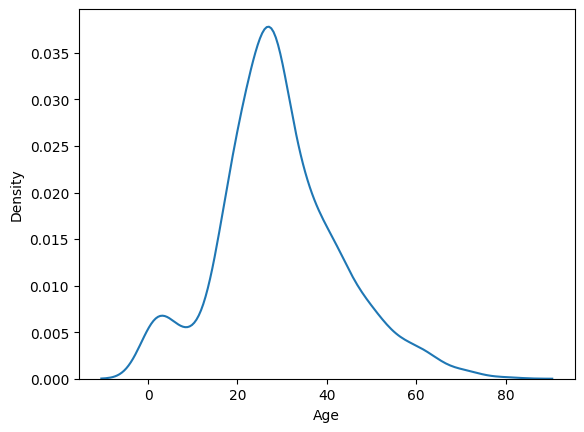

In [ ]:
sns.kdeplot(train_data['Age'])

<Axes: >

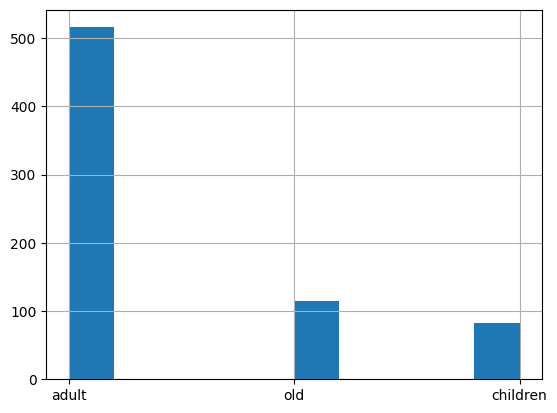

In [ ]:
train_data['Age_stage'].hist()

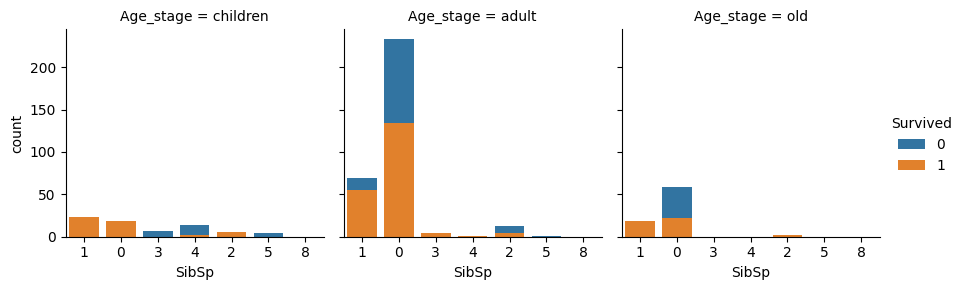

In [ ]:
g = sns.FacetGrid(train_data, col='Age_stage', hue='Survived')
g.map(sns.countplot, 'SibSp', order=train_data['SibSp'].unique())
g.add_legend()

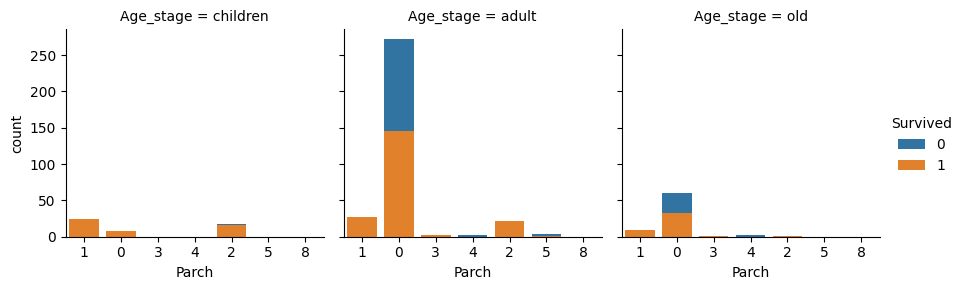

In [ ]:
g = sns.FacetGrid(train_data, col='Age_stage', hue='Survived')
g.map(sns.countplot, 'Parch', order=train_data['SibSp'].unique())
g.add_legend()

<Axes: xlabel='Embarked', ylabel='Age'>

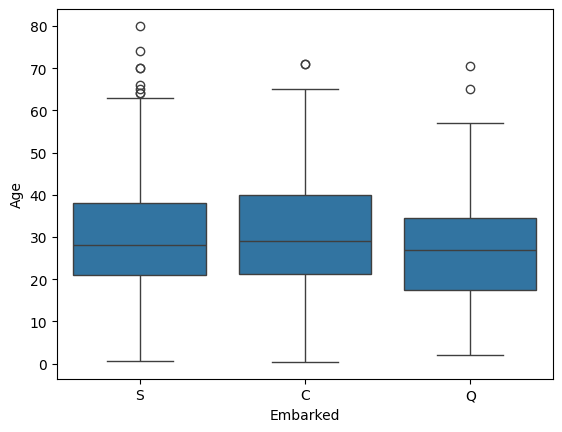

In [ ]:
sns.boxplot(x='Embarked', y='Age', data=train_data)

## Pclass

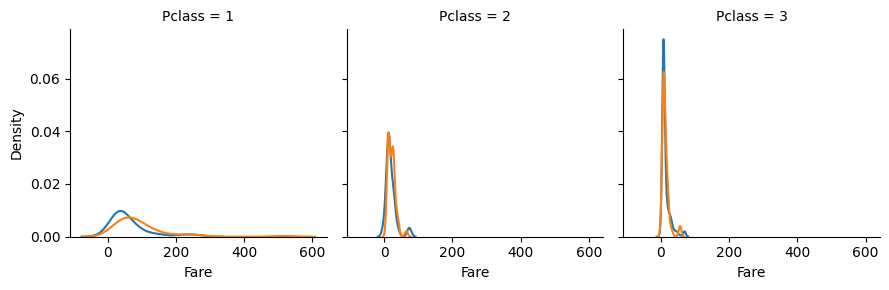

In [23]:
g = sns.FacetGrid(
    train_data,
    col='Pclass',
    hue='Survived'
)
g.map(sns.kdeplot, 'Fare')

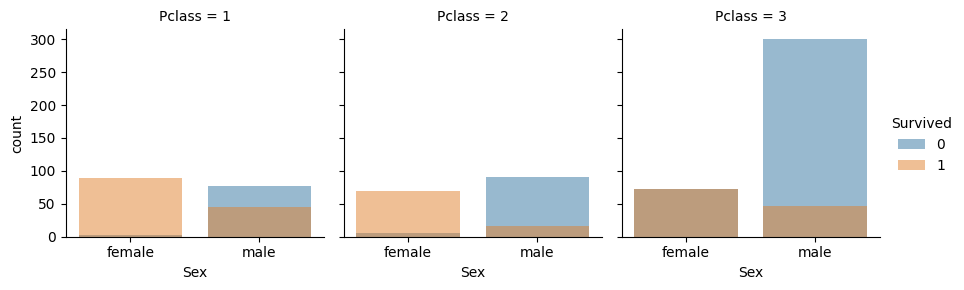

In [ ]:
g = sns.FacetGrid(train_data.dropna(subset=['Embarked']), col='Pclass', hue='Survived')
g.map(sns.cot, 'Sex', alpha=0.5, order=np.unique(train_data['Sex']))
g.add_legend()

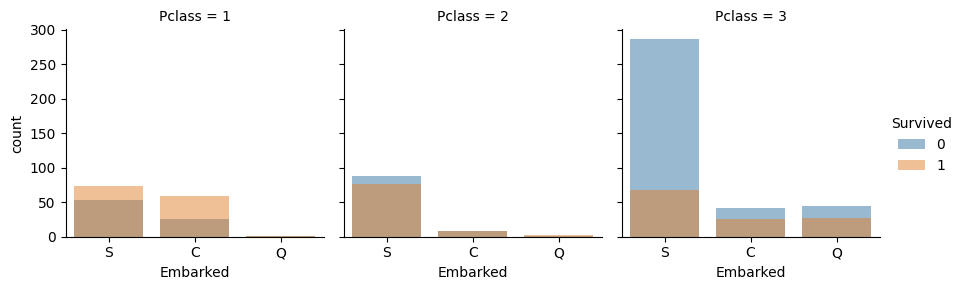

In [ ]:
g = sns.FacetGrid(train_data.dropna(subset=['Embarked']), col='Pclass', hue='Survived')
g.map(sns.countplot, 'Embarked', alpha=0.5, order=['S', 'C', 'Q'])
g.add_legend()

## Embarked

In [ ]:
tmp_data = train_data.dropna(subset=['Embarked']).replace({'Embarked': {'S': 1, 'C': 2, 'Q': 3}})
mi_null = []

for _ in range(100):
    y_perm = np.random.permutation(tmp_data['Survived'])
    mi_null.append(mutual_info_classif(tmp_data[['Embarked']], y_perm, discrete_features=True, random_state=42)[0])

threshold = np.percentile(mi_null, 95)
print(threshold)

mi_vals = []
for _ in range(100):
    mi_vals.append(mutual_info_classif(tmp_data[['Embarked']], tmp_data['Survived'], discrete_features=True, random_state=42)[0])
if np.mean(mi_vals) > threshold:
    print("Embarked значимый")

/tmp/ipykernel_55/1557640774.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmp_data = train_data.dropna(subset=['Embarked']).replace({'Embarked': {'S': 1, 'C': 2, 'Q': 3}})


0.0031598178539010927
Embarked значимый


<Axes: >

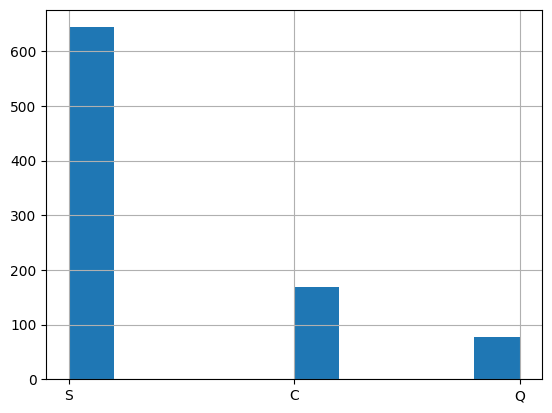

In [49]:
train_data.dropna(subset=['Embarked'])['Embarked'].hist()

## Sex

In [ ]:
train_data[train_data['Sex'] == 'female']['Survived'].mean()

np.float64(0.7420382165605095)

In [ ]:
dead_women = train_data[(train_data['Sex'] == 'female') & (train_data['Survived'] == 0)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
18,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
38,39,0,3,"Vander Planke, Miss. Augusta Maria",female,18.0,2,0,345764,18.0000,NaN,S
40,41,0,3,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",female,40.0,1,0,7546,9.4750,NaN,S


## Cabin

In [26]:
train_data['Cabin_first'] = train_data['Cabin'].str[0]
train_data.groupby('Cabin_first')['Fare'].mean()

,Fare
Cabin_first,
A,39.623887
B,113.505764
C,100.151341
D,57.244576
E,46.026694
F,18.696792
G,13.581250
T,35.500000
